# PTCG replay data miner

This notebook turns public simulation episodes from
**The Pokémon Company - PTCG AI Battle Challenge Simulation** into analysis-ready
battle data.

It is inspired by Sławek Biel's
["Am I in the top 10% replays yet?"](https://www.kaggle.com/code/slawekbiel/am-i-in-the-top-10-replays-yet),
but the default path here is lighter for PTCG:

- list public episodes for recent submissions through the Kaggle competition API;
- download the selected replay JSON files;
- parse each battle into rows with teams, winner, first player, deck signatures,
  detected archetypes, and card-level deck lists;
- write reusable outputs to `/kaggle/working/`.

The daily PTCG episode datasets can be very large, so this notebook does not
download a 20GB daily replay archive by default. The API route gives a practical
"run it and get battle data" workflow for participants.



In [1]:
from __future__ import annotations

import json
import math
import os
import sys
import time
from collections import Counter
from datetime import datetime, timezone
from pathlib import Path
from typing import Any

os.environ.setdefault("PANDAS_USE_NUMEXPR", "0")

import matplotlib

if not Path("/kaggle/working").exists():
    matplotlib.use("Agg")
    # Some local Anaconda installs ship a NumPy-incompatible numexpr build.
    # Pandas treats numexpr as optional, so hiding it locally keeps smoke-test
    # output clean without changing Kaggle notebook behavior.
    sys.modules.setdefault("numexpr", None)

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display



## Configuration

Good defaults:

- Leave `SUBMISSION_IDS` empty to use your recent complete submissions.
- Set `TEAM_NAME` if you want opponent and win-rate summaries from your team's
  point of view. If empty, the notebook tries to infer it from your submissions.
- Keep `MAX_REPLAYS_TO_DOWNLOAD` modest while iterating. Replay files can be a
  few MB each.



In [2]:
COMPETITION = "pokemon-tcg-ai-battle"

# Fill this in if you want a team-centric summary. Example: "Jiachen Li".
TEAM_NAME = ""

# Optional explicit submission ids. If empty, the notebook uses your recent
# complete submissions returned by the Kaggle API.
SUBMISSION_IDS: list[int] = []

RECENT_SUBMISSIONS_TO_USE = 4
SUBMISSION_PAGE_SIZE = 20
MAX_REPLAYS_TO_DOWNLOAD = 40
DOWNLOAD_SLEEP_SECONDS = 0.5
MAX_DOWNLOAD_RETRIES = 5

WORK_DIR = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path("ptcg_replay_work")
TEMP_DIR = (
    Path("/kaggle/temp")
    if Path("/kaggle/temp").exists()
    else Path("/tmp")
    if Path("/kaggle/working").exists() and Path("/tmp").exists()
    else WORK_DIR
)
REPLAY_DIR = TEMP_DIR / "ptcg_replay_cache"
OUTPUT_DIR = WORK_DIR / "ptcg_replay_outputs"
CACHE_REPLAYS = True

WORK_DIR.mkdir(parents=True, exist_ok=True)
TEMP_DIR.mkdir(parents=True, exist_ok=True)
REPLAY_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("work dir:", WORK_DIR.resolve())
print("temp dir:", TEMP_DIR.resolve())
print("replay dir:", REPLAY_DIR.resolve())
print("output dir:", OUTPUT_DIR.resolve())



work dir: /kaggle/working
temp dir: /tmp
replay dir: /tmp/ptcg_replay_cache
output dir: /kaggle/working/ptcg_replay_outputs


## Helpers



In [3]:
def as_plain_dict(obj: Any) -> dict[str, Any]:
    """Convert Kaggle SDK objects and nested values into plain JSON-like dicts."""
    if obj is None:
        return {}
    if isinstance(obj, dict):
        return {k: normalize_value(v) for k, v in obj.items()}
    if hasattr(obj, "to_dict"):
        return {k: normalize_value(v) for k, v in obj.to_dict().items()}
    raw = getattr(obj, "__dict__", {})
    return {k.lstrip("_"): normalize_value(v) for k, v in raw.items() if not k.startswith("__")}


def normalize_value(value: Any) -> Any:
    if isinstance(value, (list, tuple)):
        return [normalize_value(v) for v in value]
    if isinstance(value, dict):
        return {k: normalize_value(v) for k, v in value.items()}
    if isinstance(value, datetime):
        return value.isoformat()
    if hasattr(value, "name") and hasattr(value, "value"):
        return value.name
    return value


def first_existing_path(candidates: list[Path]) -> Path | None:
    for path in candidates:
        if path.exists():
            return path
    return None


def first_present_column(df: pd.DataFrame, names: list[str]) -> str | None:
    for name in names:
        if name in df.columns:
            return name
    return None


def load_card_table() -> pd.DataFrame:
    candidates = [
        Path("/kaggle/input/pokemon-tcg-ai-battle/EN_Card_Data.csv"),
        Path("/kaggle/input/the-pokemon-company-ptcg-ai-battle-challenge-simulation/EN_Card_Data.csv"),
        Path("/kaggle/input/the-pokmon-company-ptcg-ai-battle/EN_Card_Data.csv"),
        Path("/kaggle/input/datasets/competitions/pokemon-tcg-ai-battle/EN_Card_Data.csv"),
        Path("data/official/EN_Card_Data.csv"),
        Path("../data/official/EN_Card_Data.csv"),
    ]
    card_path = first_existing_path(candidates)
    if card_path is None and Path("/kaggle/input").exists():
        matches = sorted(Path("/kaggle/input").rglob("EN_Card_Data.csv"))
        if not matches:
            matches = sorted(Path("/kaggle/input").rglob("*Card_Data.csv"))
        card_path = matches[0] if matches else None
    if card_path is None:
        display(Markdown("⚠️ `EN_Card_Data.csv` was not found. Deck IDs will still be parsed, but card names may be missing."))
        return pd.DataFrame(columns=["card_id", "card_name", "card_kind"])

    raw = pd.read_csv(card_path, encoding="utf-8-sig")
    table = pd.DataFrame(
        {
            "card_id": raw.iloc[:, 0].astype(int),
            "card_name": raw.iloc[:, 1].astype(str),
            "card_kind": raw.iloc[:, 4].astype(str),
        }
    )
    print("loaded card table:", card_path, "rows:", len(table))
    return table


cards_df = load_card_table()
CARD_NAME = dict(zip(cards_df["card_id"], cards_df["card_name"]))
CARD_KIND = dict(zip(cards_df["card_id"], cards_df["card_kind"]))


def card_name(card_id: int) -> str:
    return CARD_NAME.get(int(card_id), str(card_id))


def is_pokemon_card(card_id: int) -> bool:
    kind = CARD_KIND.get(int(card_id), "")
    return "Pok" in kind


ARCHETYPE_MARKERS: list[tuple[str, list[str]]] = [
    ("Marnie Grimmsnarl", ["Marnie's Grimmsnarl ex"]),
    ("Mega Lucario", ["Mega Lucario ex"]),
    ("Archaludon", ["Archaludon ex"]),
    ("Great Tusk Crustle", ["Great Tusk", "Crustle"]),
    ("Crustle Wall", ["Crustle"]),
    ("Dragapult", ["Dragapult ex"]),
    ("Mega Starmie", ["Mega Starmie ex"]),
    ("Mega Gardevoir", ["Mega Gardevoir ex"]),
    ("Alakazam", ["Alakazam"]),
    ("Iono Bellibolt", ["Iono's Bellibolt ex", "Iono’s Bellibolt ex"]),
    ("Festival Lead", ["Dipplin"]),
    ("Hop Trevenant", ["Hop's Trevenant"]),
    ("Mega Kangaskhan", ["Mega Kangaskhan ex"]),
    ("Chandelure", ["Chandelure"]),
    ("Other", []),
]


def deck_counter(deck: list[int]) -> Counter[str]:
    return Counter(card_name(card_id) for card_id in deck)


def decklist_signature(deck: list[int], only_pokemon: bool = False, limit: int = 16) -> str:
    if only_pokemon:
        ids = [card_id for card_id in deck if is_pokemon_card(card_id)]
    else:
        ids = list(deck)
    counts = Counter(ids)
    items = []
    for card_id, count in counts.most_common(limit):
        items.append(f"{card_name(card_id)} x{count}")
    return "; ".join(items)


def classify_archetype(deck: list[int]) -> str:
    names = deck_counter(deck)
    for archetype, markers in ARCHETYPE_MARKERS:
        if not markers:
            continue
        if all(names[marker] > 0 for marker in markers):
            return archetype
    return "Other"


def winner_from_rewards(team_names: list[str], rewards: list[float | int | None]) -> str:
    numeric = [-math.inf if reward is None else float(reward) for reward in rewards]
    if not numeric or len(set(numeric)) == 1:
        return "draw"
    return team_names[max(range(len(numeric)), key=lambda i: numeric[i])]


def first_player_from_steps(steps: list[Any], team_names: list[str]) -> str:
    for step in steps[2:]:
        for seat_payload in step:
            current = (seat_payload.get("observation") or {}).get("current") or seat_payload.get("current")
            if current and current.get("firstPlayer", -1) >= 0:
                idx = int(current["firstPlayer"])
                if 0 <= idx < len(team_names):
                    return team_names[idx]
    return ""


def extract_decks(steps: list[Any]) -> list[list[int]]:
    if len(steps) > 1:
        decks = []
        for seat in range(2):
            action = steps[1][seat].get("action", [])
            if isinstance(action, list) and len(action) == 60 and all(isinstance(x, int) for x in action):
                decks.append(action)
        if len(decks) == 2:
            return decks

    # Fallback: some replays expose the initial deck lists inside visualize.
    visualize = steps[0][0].get("visualize", []) if steps else []
    if visualize and isinstance(visualize[0].get("action"), list):
        decks = visualize[0]["action"]
        if len(decks) == 2:
            return decks
    return [[], []]


def parse_replay(path: Path, episode_meta: dict[str, Any] | None = None) -> tuple[dict[str, Any], list[dict[str, Any]]]:
    replay = json.loads(path.read_text(encoding="utf-8"))
    info = replay.get("info", {})
    team_names = list(info.get("TeamNames") or ["seat0", "seat1"])
    rewards = list(replay.get("rewards") or [None, None])
    steps = replay.get("steps") or []
    decks = extract_decks(steps)
    winner = winner_from_rewards(team_names, rewards)
    first_player = first_player_from_steps(steps, team_names)
    episode_id = int(info.get("EpisodeId") or path.stem.replace("episode-", "").replace("-replay", ""))

    row: dict[str, Any] = {
        "episode_id": episode_id,
        "replay_file": str(path),
        "steps": len(steps),
        "team_0": team_names[0] if len(team_names) > 0 else "",
        "team_1": team_names[1] if len(team_names) > 1 else "",
        "reward_0": rewards[0] if len(rewards) > 0 else None,
        "reward_1": rewards[1] if len(rewards) > 1 else None,
        "winner": winner,
        "first_player": first_player,
        "seat_0_archetype": classify_archetype(decks[0]),
        "seat_1_archetype": classify_archetype(decks[1]),
        "seat_0_pokemon": decklist_signature(decks[0], only_pokemon=True),
        "seat_1_pokemon": decklist_signature(decks[1], only_pokemon=True),
        "seat_0_deck": decklist_signature(decks[0], only_pokemon=False, limit=80),
        "seat_1_deck": decklist_signature(decks[1], only_pokemon=False, limit=80),
    }

    if episode_meta:
        row.update(
            {
                "create_time": episode_meta.get("create_time") or episode_meta.get("createTime"),
                "end_time": episode_meta.get("end_time") or episode_meta.get("endTime"),
                "episode_state": episode_meta.get("state"),
                "episode_type": episode_meta.get("type"),
                "submission_0": episode_meta.get("submission_0"),
                "submission_1": episode_meta.get("submission_1"),
                "team_id_0": episode_meta.get("team_id_0"),
                "team_id_1": episode_meta.get("team_id_1"),
            }
        )

    card_rows: list[dict[str, Any]] = []
    for seat, deck in enumerate(decks):
        counts = Counter(deck)
        for card_id, count in sorted(counts.items(), key=lambda kv: (card_name(kv[0]), kv[0])):
            card_rows.append(
                {
                    "episode_id": episode_id,
                    "seat": seat,
                    "team": team_names[seat] if seat < len(team_names) else "",
                    "card_id": card_id,
                    "card_name": card_name(card_id),
                    "card_kind": CARD_KIND.get(card_id, ""),
                    "count": count,
                }
            )
    return row, card_rows



loaded card table: /kaggle/input/competitions/pokemon-tcg-ai-battle/EN_Card_Data.csv rows: 2022


## List submissions and episodes

This cell uses Kaggle's competition API. On Kaggle, the notebook must be run by
an account that has accepted the competition rules. Locally, it uses your Kaggle
credentials.



In [4]:
from kaggle.api.kaggle_api_extended import ApiGetEpisodeReplayRequest, KaggleApi

api = KaggleApi()
api.authenticate()

if SUBMISSION_IDS:
    selected_submission_ids = [int(x) for x in SUBMISSION_IDS]
    submissions_df = pd.DataFrame({"ref": selected_submission_ids})
else:
    submissions = api.competition_submissions(COMPETITION, page_size=SUBMISSION_PAGE_SIZE) or []
    submission_rows = [as_plain_dict(s) for s in submissions]
    submissions_df = pd.DataFrame(submission_rows)
    if submissions_df.empty:
        raise RuntimeError("No submissions were returned. Set SUBMISSION_IDS manually.")

    team_col = first_present_column(submissions_df, ["team_name", "teamName"])
    if not TEAM_NAME and team_col and submissions_df[team_col].notna().any():
        TEAM_NAME = str(submissions_df[team_col].dropna().iloc[0])
        print("inferred TEAM_NAME:", TEAM_NAME)

    if "status" in submissions_df.columns:
        submissions_df = submissions_df[submissions_df["status"].astype(str).str.contains("COMPLETE", case=False, na=False)]

    selected_submission_ids = submissions_df.head(RECENT_SUBMISSIONS_TO_USE)["ref"].astype(int).tolist()

display(Markdown(f"Using submission ids: `{selected_submission_ids}`"))
display(submissions_df.head(RECENT_SUBMISSIONS_TO_USE))



inferred TEAM_NAME: Jiachen Li


Using submission ids: `[54449821, 54449681, 54418431, 54362201]`

,ref,totalBytes,date,description,fileName,publicScore,status,submittedBy,submittedByRef,teamName,url,errorDescription
0,54449821,1983241,2026-07-08T04:45:14.603Z,notebook submit: meta_a stable restore | publi...,submission.tar.gz,870.5,COMPLETE,llccqq624,llccqq624,Jiachen Li,/code/llccqq624/ptcg-meta-a-stable-submit?scri...,NaN
1,54449681,2003254,2026-07-08T04:38:18.433Z,meta_a_crustle_attackfix_v1 | only Crustle act...,submission.tar.gz,936.8,COMPLETE,llccqq624,llccqq624,Jiachen Li,/submissions/54449681/54449681.raw,NaN
2,54418431,2003409,2026-07-07T06:28:22.793Z,meta_a_tuned_v1 anti-TuskLO | local160 meta_b ...,submission.tar.gz,853.5,COMPLETE,llccqq624,llccqq624,Jiachen Li,/submissions/54418431/54418431.raw,NaN
9,54362201,2003245,2026-07-05T12:39:33.367Z,meta_a Archaludon tempo | 300 target games: 56...,submission.tar.gz,875.9,COMPLETE,llccqq624,llccqq624,Jiachen Li,/submissions/54362201/54362201.raw,NaN


In [5]:
episode_rows: list[dict[str, Any]] = []
seen_episode_ids: set[int] = set()

for submission_id in selected_submission_ids:
    episodes = api.competition_list_episodes(int(submission_id)) or []
    print(f"submission {submission_id}: {len(episodes)} episodes")
    for episode in episodes:
        ep = as_plain_dict(episode)
        ep["source_submission_id"] = int(submission_id)
        ep_id = int(ep["id"])
        if ep_id in seen_episode_ids:
            continue
        seen_episode_ids.add(ep_id)

        agents = ep.get("agents") or []
        for seat in range(2):
            agent = agents[seat] if seat < len(agents) else {}
            ep[f"team_{seat}"] = agent.get("teamName") or agent.get("team_name")
            ep[f"team_id_{seat}"] = agent.get("teamId") or agent.get("team_id")
            ep[f"submission_{seat}"] = agent.get("submissionId") or agent.get("submission_id")
            ep[f"agent_reward_{seat}"] = agent.get("reward")
        episode_rows.append(ep)

episodes_df = pd.DataFrame(episode_rows)
if episodes_df.empty:
    raise RuntimeError("No public episodes were found for the selected submissions.")

if "type" in episodes_df.columns:
    episodes_df = episodes_df[episodes_df["type"].astype(str).str.contains("PUBLIC", case=False, na=False)]
if "state" in episodes_df.columns:
    episodes_df = episodes_df[episodes_df["state"].astype(str).str.contains("COMPLETED|COMPLETE", case=False, na=False)]

episodes_df = episodes_df.sort_values("id", ascending=False).head(MAX_REPLAYS_TO_DOWNLOAD).reset_index(drop=True)
episodes_path = OUTPUT_DIR / "episodes.csv"
episodes_df.to_csv(episodes_path, index=False, encoding="utf-8-sig")

display(Markdown(f"Found `{len(episodes_df)}` public completed episodes. Saved metadata to `{episodes_path}`."))
display(episodes_df.head(10))



submission 54449821: 56 episodes
submission 54449681: 62 episodes
submission 54418431: 80 episodes
submission 54362201: 132 episodes


Found `40` public completed episodes. Saved metadata to `/kaggle/working/ptcg_replay_outputs/episodes.csv`.

,id,createTime,endTime,state,type,agents,source_submission_id,team_0,team_id_0,submission_0,agent_reward_0,team_1,team_id_1,submission_1,agent_reward_1
0,84817357,2026-07-08T09:50:20.069Z,2026-07-08T09:52:39.094Z,COMPLETED,EPISODE_TYPE_PUBLIC,"[{'submissionId': 53979833, 'reward': 1, 'team...",54449681,Lapra5,16380605,53979833,1,Jiachen Li,16381864,54449681,-1
1,84814368,2026-07-08T09:26:23.788Z,2026-07-08T09:29:08.376Z,COMPLETED,EPISODE_TYPE_PUBLIC,"[{'submissionId': 54411883, 'reward': -1, 'tea...",54449821,shallowfieldagon,16460352,54411883,-1,Jiachen Li,16381864,54449821,1
2,84811418,2026-07-08T09:02:20.509Z,2026-07-08T09:04:37.768Z,COMPLETED,EPISODE_TYPE_PUBLIC,"[{'submissionId': 54449681, 'reward': 1, 'team...",54449681,Jiachen Li,16381864,54449681,1,Matsuda040708,16378759,53767455,-1
3,84808446,2026-07-08T08:38:22.905Z,2026-07-08T08:40:48.223Z,COMPLETED,EPISODE_TYPE_PUBLIC,"[{'submissionId': 54403478, 'reward': -1, 'tea...",54449821,Pikachu,16433241,54403478,-1,Jiachen Li,16381864,54449821,1
4,84806498,2026-07-08T08:22:19.217Z,2026-07-08T08:24:46.076Z,COMPLETED,EPISODE_TYPE_PUBLIC,"[{'submissionId': 54222966, 'reward': -1, 'tea...",54449681,Furkan Pirinc,16413763,54222966,-1,Jiachen Li,16381864,54449681,1
5,84804404,2026-07-08T08:06:19.420Z,2026-07-08T08:08:39.890Z,COMPLETED,EPISODE_TYPE_PUBLIC,"[{'submissionId': 54389258, 'reward': 1, 'team...",54449681,Fakble 6,16465163,54389258,1,Jiachen Li,16381864,54449681,-1
6,84803948,2026-07-08T08:02:21.018Z,2026-07-08T08:04:36.654Z,COMPLETED,EPISODE_TYPE_PUBLIC,"[{'submissionId': 54449821, 'reward': -1, 'tea...",54449821,Jiachen Li,16381864,54449821,-1,Kohei,16372809,54447629,1
7,84803876,2026-07-08T08:02:20.922Z,2026-07-08T08:04:29.780Z,COMPLETED,EPISODE_TYPE_PUBLIC,"[{'submissionId': 54180724, 'reward': 1, 'team...",54449681,DaJimmy,16384958,54180724,1,Jiachen Li,16381864,54449681,-1
8,84803646,2026-07-08T08:02:20.595Z,2026-07-08T08:04:48.518Z,COMPLETED,EPISODE_TYPE_PUBLIC,"[{'submissionId': 54453852, 'reward': -1, 'tea...",54449821,Takaaki Matsuda,16371783,54453852,-1,Jiachen Li,16381864,54449821,1
9,84803379,2026-07-08T07:58:19.004Z,2026-07-08T08:00:45.637Z,COMPLETED,EPISODE_TYPE_PUBLIC,"[{'submissionId': 54227924, 'reward': 1, 'team...",54449821,ひげだるま(inovie株式会社),16385204,54227924,1,Jiachen Li,16381864,54449821,-1


## Download replays



In [6]:
def replay_path_for_episode(episode_id: int) -> Path:
    return REPLAY_DIR / f"episode-{episode_id}-replay.json"


def download_replay_json(api: KaggleApi, episode_id: int, destination: Path) -> None:
    """Download a replay without relying on the CLI Content-Length handler.

    Kaggle CLI versions around 2.1.0 may raise `KeyError: content-length` for
    replay responses. The lower-level SDK response still contains the bytes, so
    writing `response.content` directly is more robust.
    """
    last_error: Exception | None = None
    for attempt in range(MAX_DOWNLOAD_RETRIES):
        request = ApiGetEpisodeReplayRequest()
        request.episode_id = int(episode_id)
        try:
            with api.build_kaggle_client() as kaggle:
                response = kaggle.competitions.competition_api_client.get_episode_replay(request)
                response.raise_for_status()
                destination.write_bytes(response.content)
            if DOWNLOAD_SLEEP_SECONDS:
                time.sleep(DOWNLOAD_SLEEP_SECONDS)
            return
        except Exception as exc:
            last_error = exc
            status_code = getattr(getattr(exc, "response", None), "status_code", None)
            if status_code == 429:
                wait_seconds = min(60, 5 * (2 ** attempt))
                print(f"episode {episode_id}: 429 rate limit, retrying in {wait_seconds}s")
                time.sleep(wait_seconds)
                continue
            if attempt < MAX_DOWNLOAD_RETRIES - 1:
                wait_seconds = min(20, 2 * (attempt + 1))
                print(f"episode {episode_id}: {type(exc).__name__}, retrying in {wait_seconds}s")
                time.sleep(wait_seconds)
                continue
            break
    raise RuntimeError(f"failed to download episode {episode_id}: {last_error}")


downloaded_paths: list[Path] = []
download_errors: list[dict[str, Any]] = []
for episode_id in episodes_df["id"].astype(int).tolist():
    path = replay_path_for_episode(episode_id)
    if path.exists() and path.stat().st_size > 1000 and CACHE_REPLAYS:
        downloaded_paths.append(path)
        continue
    try:
        download_replay_json(api, int(episode_id), path)
        downloaded_paths.append(path)
    except Exception as exc:
        download_errors.append({"episode_id": int(episode_id), "error": f"{type(exc).__name__}: {exc}"})
        print(f"episode {episode_id}: skipped after download error: {exc}")

print(f"downloaded/cached {len(downloaded_paths)} replays")
print("example:", downloaded_paths[0] if downloaded_paths else None)
if not downloaded_paths:
    raise RuntimeError("No replays were downloaded. Reduce MAX_REPLAYS_TO_DOWNLOAD or try again later.")



downloaded/cached 40 replays
example: /tmp/ptcg_replay_cache/episode-84817357-replay.json


## Parse replays into battle tables



In [7]:
episode_meta_by_id = {int(row["id"]): row for row in episodes_df.to_dict("records")}
battle_rows: list[dict[str, Any]] = []
card_rows_all: list[dict[str, Any]] = []
errors: list[dict[str, str]] = []

for path in downloaded_paths:
    try:
        episode_id = int(path.stem.replace("episode-", "").replace("-replay", ""))
        row, card_rows = parse_replay(path, episode_meta_by_id.get(episode_id))
        battle_rows.append(row)
        card_rows_all.extend(card_rows)
    except Exception as exc:
        errors.append({"file": str(path), "error": f"{type(exc).__name__}: {exc}"})

battles_df = pd.DataFrame(battle_rows)
deck_cards_df = pd.DataFrame(card_rows_all)
errors_df = pd.DataFrame(errors, columns=["file", "error"])
download_errors_df = pd.DataFrame(download_errors, columns=["episode_id", "error"])

if TEAM_NAME and not battles_df.empty:
    def team_result(row: pd.Series) -> str:
        if row["winner"] == "draw":
            return "draw"
        if row["winner"] == TEAM_NAME:
            return "win"
        if row["team_0"] == TEAM_NAME or row["team_1"] == TEAM_NAME:
            return "loss"
        return "not_in_game"

    battles_df["team_of_interest"] = TEAM_NAME
    battles_df["team_result"] = battles_df.apply(team_result, axis=1)
    battles_df["our_seat"] = battles_df.apply(
        lambda r: 0 if r["team_0"] == TEAM_NAME else 1 if r["team_1"] == TEAM_NAME else None,
        axis=1,
    )
    battles_df["our_archetype"] = battles_df.apply(
        lambda r: r["seat_0_archetype"] if r["team_0"] == TEAM_NAME else r["seat_1_archetype"] if r["team_1"] == TEAM_NAME else "",
        axis=1,
    )
    battles_df["opponent"] = battles_df.apply(
        lambda r: r["team_1"] if r["team_0"] == TEAM_NAME else r["team_0"] if r["team_1"] == TEAM_NAME else "",
        axis=1,
    )
    battles_df["opponent_archetype"] = battles_df.apply(
        lambda r: r["seat_1_archetype"] if r["team_0"] == TEAM_NAME else r["seat_0_archetype"] if r["team_1"] == TEAM_NAME else "",
        axis=1,
    )

battles_path = OUTPUT_DIR / "battles.csv"
deck_cards_path = OUTPUT_DIR / "deck_cards_long.csv"
errors_path = OUTPUT_DIR / "parse_errors.csv"
download_errors_path = OUTPUT_DIR / "download_errors.csv"

battles_df.to_csv(battles_path, index=False, encoding="utf-8-sig")
deck_cards_df.to_csv(deck_cards_path, index=False, encoding="utf-8-sig")
errors_df.to_csv(errors_path, index=False, encoding="utf-8-sig")
download_errors_df.to_csv(download_errors_path, index=False, encoding="utf-8-sig")

display(Markdown(f"Saved `{len(battles_df)}` battle rows to `{battles_path}`."))
display(Markdown(f"Saved `{len(deck_cards_df)}` deck-card rows to `{deck_cards_path}`."))
if not errors_df.empty:
    display(Markdown(f"⚠️ `{len(errors_df)}` replay files failed to parse. See `{errors_path}`."))
if not download_errors_df.empty:
    display(Markdown(f"⚠️ `{len(download_errors_df)}` replay files failed to download. See `{download_errors_path}`."))

display(battles_df.head(10))



Saved `40` battle rows to `/kaggle/working/ptcg_replay_outputs/battles.csv`.

Saved `1345` deck-card rows to `/kaggle/working/ptcg_replay_outputs/deck_cards_long.csv`.

,episode_id,replay_file,steps,team_0,team_1,reward_0,reward_1,winner,first_player,seat_0_archetype,...,submission_0,submission_1,team_id_0,team_id_1,team_of_interest,team_result,our_seat,our_archetype,opponent,opponent_archetype
0,84817357,/tmp/ptcg_replay_cache/episode-84817357-replay...,110,Lapra5,Jiachen Li,1,-1,Lapra5,Lapra5,Alakazam,...,53979833,54449681,16380605,16381864,Jiachen Li,loss,1,Archaludon,Lapra5,Alakazam
1,84814368,/tmp/ptcg_replay_cache/episode-84814368-replay...,132,shallowfieldagon,Jiachen Li,-1,1,Jiachen Li,shallowfieldagon,Alakazam,...,54411883,54449821,16460352,16381864,Jiachen Li,win,1,Archaludon,shallowfieldagon,Alakazam
2,84811418,/tmp/ptcg_replay_cache/episode-84811418-replay...,143,Jiachen Li,Matsuda040708,1,-1,Jiachen Li,Matsuda040708,Archaludon,...,54449681,53767455,16381864,16378759,Jiachen Li,win,0,Archaludon,Matsuda040708,Mega Lucario
3,84808446,/tmp/ptcg_replay_cache/episode-84808446-replay...,145,Pikachu,Jiachen Li,-1,1,Jiachen Li,Pikachu,Archaludon,...,54403478,54449821,16433241,16381864,Jiachen Li,win,1,Archaludon,Pikachu,Archaludon
4,84806498,/tmp/ptcg_replay_cache/episode-84806498-replay...,133,Furkan Pirinc,Jiachen Li,-1,1,Jiachen Li,Jiachen Li,Archaludon,...,54222966,54449681,16413763,16381864,Jiachen Li,win,1,Archaludon,Furkan Pirinc,Archaludon
5,84804404,/tmp/ptcg_replay_cache/episode-84804404-replay...,127,Fakble 6,Jiachen Li,1,-1,Fakble 6,Jiachen Li,Archaludon,...,54389258,54449681,16465163,16381864,Jiachen Li,loss,1,Archaludon,Fakble 6,Archaludon
6,84803948,/tmp/ptcg_replay_cache/episode-84803948-replay...,51,Jiachen Li,Kohei,-1,1,Kohei,Kohei,Archaludon,...,54449821,54447629,16381864,16372809,Jiachen Li,loss,0,Archaludon,Kohei,Archaludon
7,84803876,/tmp/ptcg_replay_cache/episode-84803876-replay...,154,DaJimmy,Jiachen Li,1,-1,DaJimmy,Jiachen Li,Archaludon,...,54180724,54449681,16384958,16381864,Jiachen Li,loss,1,Archaludon,DaJimmy,Archaludon
8,84803646,/tmp/ptcg_replay_cache/episode-84803646-replay...,94,Takaaki Matsuda,Jiachen Li,-1,1,Jiachen Li,Jiachen Li,Archaludon,...,54453852,54449821,16371783,16381864,Jiachen Li,win,1,Archaludon,Takaaki Matsuda,Archaludon
9,84803379,/tmp/ptcg_replay_cache/episode-84803379-replay...,144,ひげだるま(inovie株式会社),Jiachen Li,1,-1,ひげだるま(inovie株式会社),ひげだるま(inovie株式会社),Alakazam,...,54227924,54449821,16385204,16381864,Jiachen Li,loss,1,Archaludon,ひげだるま(inovie株式会社),Alakazam


## Summary tables



In [8]:
summary_tables: dict[str, pd.DataFrame] = {}

if TEAM_NAME and "team_result" in battles_df.columns:
    team_games = battles_df[battles_df["team_result"] != "not_in_game"].copy()
    if not team_games.empty:
        matchup_summary = (
            team_games.groupby(["our_archetype", "opponent_archetype", "team_result"])
            .size()
            .unstack(fill_value=0)
            .reset_index()
        )
        for col in ["win", "loss", "draw"]:
            if col not in matchup_summary:
                matchup_summary[col] = 0
        matchup_summary["games"] = matchup_summary[["win", "loss", "draw"]].sum(axis=1)
        matchup_summary["win_rate"] = (matchup_summary["win"] / matchup_summary["games"]).round(4)
        matchup_summary = matchup_summary.sort_values(["games", "win_rate"], ascending=[False, False])
        summary_tables["matchup_summary"] = matchup_summary

        opponent_summary = (
            team_games.groupby(["opponent", "team_result"])
            .size()
            .unstack(fill_value=0)
            .reset_index()
        )
        for col in ["win", "loss", "draw"]:
            if col not in opponent_summary:
                opponent_summary[col] = 0
        opponent_summary["games"] = opponent_summary[["win", "loss", "draw"]].sum(axis=1)
        opponent_summary["win_rate"] = (opponent_summary["win"] / opponent_summary["games"]).round(4)
        opponent_summary = opponent_summary.sort_values(["games", "win_rate"], ascending=[False, False])
        summary_tables["opponent_summary"] = opponent_summary

archetype_matrix = (
    battles_df.groupby(["seat_0_archetype", "seat_1_archetype", "winner"])
    .size()
    .reset_index(name="games")
    .sort_values("games", ascending=False)
)
summary_tables["archetype_matrix"] = archetype_matrix

for name, df in summary_tables.items():
    path = OUTPUT_DIR / f"{name}.csv"
    df.to_csv(path, index=False, encoding="utf-8-sig")
    display(Markdown(f"### {name} → `{path}`"))
    display(df.head(20))



### matchup_summary → `/kaggle/working/ptcg_replay_outputs/matchup_summary.csv`

team_result,our_archetype,opponent_archetype,loss,win,draw,games,win_rate
1,Archaludon,Archaludon,6,11,0,17,0.6471
0,Archaludon,Alakazam,6,4,0,10,0.4000
6,Archaludon,Mega Lucario,0,3,0,3,1.0000
3,Archaludon,Dragapult,1,2,0,3,0.6667
7,Archaludon,Mega Starmie,0,2,0,2,1.0000
5,Archaludon,Marnie Grimmsnarl,1,1,0,2,0.5000
2,Archaludon,Crustle Wall,0,1,0,1,1.0000
4,Archaludon,Great Tusk Crustle,0,1,0,1,1.0000
8,Archaludon,Other,0,1,0,1,1.0000


### opponent_summary → `/kaggle/working/ptcg_replay_outputs/opponent_summary.csv`

team_result,opponent,loss,win,draw,games,win_rate
19,OzanM.,1,1,0,2,0.5
1,Arthurs Torres24,0,1,0,1,1.0
2,Aryan Yadav,0,1,0,1,1.0
3,Banjo,0,1,0,1,1.0
7,Fernando,0,1,0,1,1.0
8,Fomo,0,1,0,1,1.0
9,Furkan Pirinc,0,1,0,1,1.0
10,GarlicToday,0,1,0,1,1.0
11,Hongbin Guokaggle,0,1,0,1,1.0
12,Ikki Katsuyama,0,1,0,1,1.0


### archetype_matrix → `/kaggle/working/ptcg_replay_outputs/archetype_matrix.csv`

,seat_0_archetype,seat_1_archetype,winner,games
11,Archaludon,Archaludon,Jiachen Li,11
19,Archaludon,Mega Lucario,Jiachen Li,3
1,Alakazam,Archaludon,Jiachen Li,2
6,Archaludon,Alakazam,Jiachen Li,2
15,Archaludon,Dragapult,Jiachen Li,2
22,Mega Starmie,Archaludon,Jiachen Li,2
2,Alakazam,Archaludon,Lapra5,1
0,Alakazam,Archaludon,Ajishio,1
7,Archaludon,Alakazam,takaygiiiiiiii,1
5,Archaludon,Alakazam,Brady Meighan,1


## Quick visuals



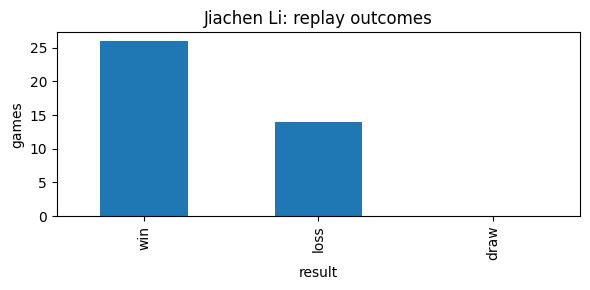

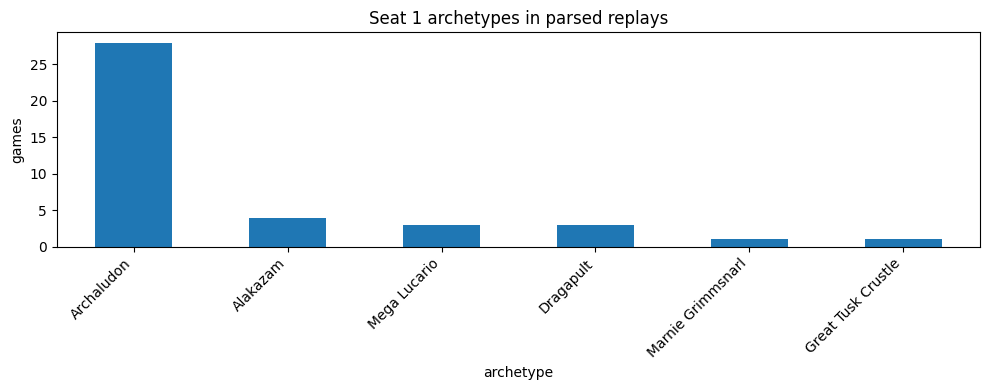

In [9]:
if TEAM_NAME and "team_result" in battles_df.columns:
    plot_df = battles_df[battles_df["team_result"].isin(["win", "loss", "draw"])]
    if not plot_df.empty:
        ax = plot_df["team_result"].value_counts().reindex(["win", "loss", "draw"]).fillna(0).plot(
            kind="bar", figsize=(6, 3), title=f"{TEAM_NAME}: replay outcomes"
        )
        ax.set_xlabel("result")
        ax.set_ylabel("games")
        plt.tight_layout()
        plt.show()

if not battles_df.empty:
    ax = battles_df["seat_1_archetype"].value_counts().head(12).plot(
        kind="bar", figsize=(10, 4), title="Seat 1 archetypes in parsed replays"
    )
    ax.set_xlabel("archetype")
    ax.set_ylabel("games")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()



## Output manifest



In [10]:
manifest = {
    "competition": COMPETITION,
    "team_name": TEAM_NAME,
    "selected_submission_ids": selected_submission_ids,
    "episodes": int(len(episodes_df)),
    "parsed_battles": int(len(battles_df)),
    "download_errors": int(len(download_errors_df)),
    "parse_errors": int(len(errors_df)),
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "outputs": {
        "episodes": str(episodes_path),
        "battles": str(battles_path),
        "deck_cards_long": str(deck_cards_path),
        "download_errors": str(download_errors_path),
        "parse_errors": str(errors_path),
        **{name: str(OUTPUT_DIR / f"{name}.csv") for name in summary_tables},
    },
}

manifest_path = OUTPUT_DIR / "manifest.json"
manifest_path.write_text(json.dumps(manifest, indent=2, ensure_ascii=False), encoding="utf-8")

display(Markdown("## Done"))
display(Markdown(f"Output manifest: `{manifest_path}`"))
print(json.dumps(manifest, indent=2, ensure_ascii=False))


## Done

Output manifest: `/kaggle/working/ptcg_replay_outputs/manifest.json`

{
  "competition": "pokemon-tcg-ai-battle",
  "team_name": "Jiachen Li",
  "selected_submission_ids": [
    54449821,
    54449681,
    54418431,
    54362201
  ],
  "episodes": 40,
  "parsed_battles": 40,
  "download_errors": 0,
  "parse_errors": 0,
  "created_at_utc": "2026-07-08T10:07:34.421106+00:00",
  "outputs": {
    "episodes": "/kaggle/working/ptcg_replay_outputs/episodes.csv",
    "battles": "/kaggle/working/ptcg_replay_outputs/battles.csv",
    "deck_cards_long": "/kaggle/working/ptcg_replay_outputs/deck_cards_long.csv",
    "download_errors": "/kaggle/working/ptcg_replay_outputs/download_errors.csv",
    "parse_errors": "/kaggle/working/ptcg_replay_outputs/parse_errors.csv",
    "matchup_summary": "/kaggle/working/ptcg_replay_outputs/matchup_summary.csv",
    "opponent_summary": "/kaggle/working/ptcg_replay_outputs/opponent_summary.csv",
    "archetype_matrix": "/kaggle/working/ptcg_replay_outputs/archetype_matrix.csv"
  }
}
